# Stock Return Prediction — Improved Linear Models (v3)
---

## Key Insight Driving This Redesign

Year-level mean returns vary massively — the model was partially learning *when* (bull vs bear year), not *who* (which stocks outperform peers).

| Year (features) | Predicts | Mean Return | % Positive |
|----------------|----------|-------------|------------|
| 2014 | 2015 | -5.00% | 42.5% |
| 2015 | 2016 | +20.48% | 70.0% |
| 2016 | 2017 | +17.56% | 66.9% |
| 2017 | 2018 | -13.46% | 27.5% |
| 2018 (test) | 2019 | +19.66% | 69.2% |

The test year (2019) had 69.2% positive returns — a naive always-predict-up model already scores 69.2% hit rate. The previous ElasticNet's 70.55% was only 1.37 pp better than doing nothing.

## Improvements in This Version

| Issue | Before | Now |
|-------|--------|-----|
| Target distribution shift | Train on raw returns | **CS z-score target within each year** |
| Hit Rate inflation | Not compared to naive | **Reports incremental skill over naive baseline** |
| Feature selection | Pearson r with raw returns | **Spearman IC with CS-normalised target** |
| Lasso degenerate solutions | Same alpha space for all | **Model-specific alpha bounds** |
| Optuna closure bug | `def objective` in for-loop | **Factory function `make_objective()`** |
| Interaction signals | None | **Value x Quality, Growth x Quality** |
| Delta features | 4 | **6 (added GrossMargin, OperatingMargin)** |

## Cell 0 — Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr, pearsonr

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import VarianceThreshold

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi']        = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('Libraries imported.')

Libraries imported.


---
## Step 1 — Load & Combine Data

In [3]:
df = pd.read_csv("cleaned_dataset.csv")
df  = df.sort_values(['Ticker', 'Year']).reset_index(drop=True)

print(f'Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Years  : {sorted(df["Year"].unique())}')
print(f'Tickers: {df["Ticker"].nunique():,}')
print()
print('Year-level return statistics — reveals market-timing confound:')
stats = df.groupby('Year')['Stock_Return'].agg(
    Mean='mean', Std='std',
    PctPositive=lambda x: (x > 0).mean()
).round(3)
print(stats.to_string())

Shape  : 22,031 rows x 207 columns
Years  : [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
Tickers: 4,980

Year-level return statistics — reveals market-timing confound:
         Mean     Std  PctPositive
Year                              
2014  -5.0010 43.1560       0.4250
2015  20.4750 54.2120       0.7000
2016  17.5570 55.2260       0.6690
2017 -13.4630 40.8490       0.2750
2018  19.6650 57.3040       0.6920


---
## Step 2 — Target Variable: Cross-Sectional Z-Score

Raw `Stock_Return` mixes two signals:
1. **Market-level return** — which year is bullish (unpredictable from fundamentals)
2. **Firm-level relative return** — which stocks outperform peers (what we want)

By z-scoring within each year, signal (1) is removed entirely:

```
cs_target_t = (Stock_Return_t - mean_year_t) / std_year_t
```

The Spearman IC between cs_target predictions and raw returns is **identical** to IC between
raw predictions and raw returns — rank is invariant to monotonic transformations. Evaluation
is therefore unaffected; only the training objective becomes cleaner.

In [4]:
TARGET_RAW = 'Stock_Return'

# Cross-sectional z-score WITHIN each year — removes market-level bias
df['cs_target'] = df.groupby('Year')[TARGET_RAW].transform(
    lambda x: (x - x.mean()) / x.std()
)

print('CS-normalised target verification (should be mean=0, std=1 per year):')
check = df.groupby('Year')['cs_target'].agg(['mean', 'std']).round(4)
print(check.to_string())

print()
print('Naive always-predict-up hit rate per year (minimum bar to beat):')
naive = df.groupby('Year')[TARGET_RAW].apply(lambda x: (x > 0).mean()).round(4)
print(naive.to_string())

CS-normalised target verification (should be mean=0, std=1 per year):
        mean    std
Year               
2014  0.0000 1.0000
2015 -0.0000 1.0000
2016 -0.0000 1.0000
2017 -0.0000 1.0000
2018 -0.0000 1.0000

Naive always-predict-up hit rate per year (minimum bar to beat):
Year
2014   0.4246
2015   0.6996
2016   0.6695
2017   0.2752
2018   0.6918


---
## Step 3 — Define Features & Remove Leakage

In [5]:
LEAKAGE   = ['Stock_Return', 'Class', 'Return_Direction', 'cs_target']
ID_COLS   = ['Ticker', 'Year']
CAT_FEATS = ['Sector']
TARGET_COL = 'cs_target'    # train on CS-normalised target
TARGET_RAW = 'Stock_Return' # portfolio metrics use actual raw returns

exclude = LEAKAGE + ID_COLS + CAT_FEATS
NUMERIC_RAW = [
    c for c in df.columns
    if c not in exclude
    and df[c].dtype in [np.float64, np.float32, np.int64, np.int32]
]

print(f'Numeric features : {len(NUMERIC_RAW)}')
print(f'Categorical      : {CAT_FEATS}')
print(f'Excluded (leakage/id): {[c for c in LEAKAGE if c in df.columns]}')

miss = df[NUMERIC_RAW].isnull().mean()
print(f'Features with >50% missing : {(miss > 0.5).sum()}')
print(f'Features with   0% missing : {(miss == 0.0).sum()}')

Numeric features : 201
Categorical      : ['Sector']
Excluded (leakage/id): ['Stock_Return', 'Class', 'Return_Direction', 'cs_target']
Features with >50% missing : 0
Features with   0% missing : 201


---
## Step 4 — Time-Based Train / Test Split

In [6]:
TRAIN_YEARS = [2014, 2015, 2016, 2017]
TEST_YEAR   = 2018

train_df = df[df['Year'].isin(TRAIN_YEARS)].copy().reset_index(drop=True)
test_df  = df[df['Year'] == TEST_YEAR].copy().reset_index(drop=True)

y_train     = train_df[TARGET_COL].copy()   # CS-normalised: for training
y_train_raw = train_df[TARGET_RAW].copy()   # raw: for CV portfolio metrics
y_test      = test_df[TARGET_COL].copy()    # CS-normalised: for IC eval
y_test_raw  = test_df[TARGET_RAW].copy()    # raw: for portfolio metrics

print(f'Train (2014-2017): {len(train_df):,} rows')
print(f'Test  (2018)     : {len(test_df):,} rows')
print()
naive_test = float((y_test_raw > 0).mean())
print(f'Naive always-up hit rate on TEST : {naive_test:.4f}')
print('This is the minimum any useful model must beat on directional accuracy.')

CV_SPLITS = [
    ([2014],             2015),
    ([2014, 2015],       2016),
    ([2014, 2015, 2016], 2017),
]

Train (2014-2017): 17,641 rows
Test  (2018)     : 4,390 rows

Naive always-up hit rate on TEST : 0.6918
This is the minimum any useful model must beat on directional accuracy.


---
## Step 5 — Feature Engineering

All statistics fitted on **training data only**. Applied to test data using training parameters.

| Step | Transform | Purpose |
|------|-----------|---------|
| 5.1 | Winsorisation (1-99th pct) | Clip financial data outliers |
| 5.2 | Signed-log on size variables | Compress right-skewed distributions |
| 5.3 | Cross-sectional z-score per year | Remove year-scale differences |
| 5.4 | Sector-relative adjustment | Remove sector-level systematic bias |
| 5.5 | Delta features (YoY changes) | Momentum / change signals |
| 5.6 | Interaction features | Cross-factor signals (value x quality, etc.) |

In [7]:
# 5.1  Winsorisation
print('5.1  Winsorisation (1st-99th pct, fit on train) ...')
winsor_bounds = {}
X_tr_w = train_df[NUMERIC_RAW].copy()

for col in NUMERIC_RAW:
    lo = X_tr_w[col].quantile(0.01)
    hi = X_tr_w[col].quantile(0.99)
    winsor_bounds[col] = (lo, hi)
    X_tr_w[col] = X_tr_w[col].clip(lo, hi)

X_te_w = test_df[NUMERIC_RAW].copy()
for col, (lo, hi) in winsor_bounds.items():
    X_te_w[col] = X_te_w[col].clip(lo, hi)

print('     Done')

# 5.2  Signed-log on size variables
print('5.2  Signed-log transformation ...')
SIZE_VARS = [c for c in ['Revenue', 'Total assets', 'Market Cap', 'Enterprise Value']
             if c in NUMERIC_RAW]

def signed_log(s):
    return np.sign(s) * np.log1p(np.abs(s))

for col in SIZE_VARS:
    X_tr_w[col] = signed_log(X_tr_w[col])
    X_te_w[col] = signed_log(X_te_w[col])
print(f'     Applied to: {SIZE_VARS}')
print('     Done')

5.1  Winsorisation (1st-99th pct, fit on train) ...
     Done
5.2  Signed-log transformation ...
     Applied to: ['Revenue', 'Total assets', 'Market Cap', 'Enterprise Value']
     Done


In [8]:
# 5.3  Cross-sectional z-score per year (fit on train stats only)
print('5.3  Cross-sectional z-score ...')
year_stats = {}
for yr in TRAIN_YEARS:
    mask = (train_df['Year'] == yr)
    year_stats[yr] = {
        'mean': X_tr_w[mask].mean(),
        'std':  X_tr_w[mask].std().replace(0, 1),
    }

def cs_std(X_feat, year_series, stats, fallback=2017):
    out = X_feat.copy()
    for yr in year_series.unique():
        ref  = yr if yr in stats else fallback
        mask = (year_series == yr)
        out.loc[mask] = (X_feat.loc[mask] - stats[ref]['mean']) / stats[ref]['std']
    return out

X_tr_cs = cs_std(X_tr_w, train_df['Year'], year_stats)
X_te_cs = cs_std(X_te_w, test_df['Year'],  year_stats)
print('     Done')

# 5.4  Sector-relative adjustment
print('5.4  Sector-relative adjustment ...')
sector_meds = {}
for sec in train_df['Sector'].unique():
    mask = (train_df['Sector'] == sec)
    sector_meds[sec] = X_tr_cs[mask].median()

fallback_sec = train_df['Sector'].mode()[0]

def sector_adj(X_feat, sector_series, meds, fallback):
    out = X_feat.copy()
    for sec in sector_series.unique():
        med  = meds.get(sec, meds[fallback])
        mask = (sector_series == sec)
        out.loc[mask] = X_feat.loc[mask] - med
    return out

X_tr_sa = sector_adj(X_tr_cs, train_df['Sector'], sector_meds, fallback_sec)
X_te_sa = sector_adj(X_te_cs, test_df['Sector'],  sector_meds, fallback_sec)
print('     Done')

5.3  Cross-sectional z-score ...
     Done
5.4  Sector-relative adjustment ...
     Done


In [9]:
# 5.5  Delta features (YoY changes in key ratios)
print('5.5  Delta features ...')
DELTA_MAP = {
    'd_NetProfitMargin' : 'Net Profit Margin',
    'd_ROE'             : 'ROE',
    'd_DebtToEquity'    : 'Debt to Equity',
    'd_RevenueGrowth'   : 'Revenue Growth',
    'd_GrossMargin'     : 'Gross Margin',
    'd_OperatingMargin' : 'EBIT Margin',
}

for new_col, src in DELTA_MAP.items():
    if src in df.columns:
        df[new_col] = df.groupby('Ticker')[src].diff()

DELTA_COLS = [c for c in DELTA_MAP if c in df.columns]

delta_tr = df[df['Year'].isin(TRAIN_YEARS)][DELTA_COLS].reset_index(drop=True)
delta_te = df[df['Year'] == TEST_YEAR][DELTA_COLS].reset_index(drop=True)

# Winsorise delta features using training bounds
for col in DELTA_COLS:
    lo = delta_tr[col].quantile(0.01)
    hi = delta_tr[col].quantile(0.99)
    delta_tr[col] = delta_tr[col].clip(lo, hi)
    delta_te[col] = delta_te[col].clip(lo, hi)

print(f'     Created: {DELTA_COLS}')
print('     Done')

5.5  Delta features ...
     Created: ['d_NetProfitMargin', 'd_ROE', 'd_DebtToEquity', 'd_RevenueGrowth', 'd_GrossMargin', 'd_OperatingMargin']
     Done


In [10]:
# 5.6  Interaction features between factor groups
print('5.6  Interaction features ...')

# Find representative feature from each group
VALUE_PROXY   = next((f for f in ['priceToBookRatio', 'priceEarningsRatio', 'priceFairValue']
                      if f in NUMERIC_RAW), None)
QUALITY_PROXY = next((f for f in ['returnOnEquity', 'ROE', 'returnOnAssets']
                      if f in NUMERIC_RAW), None)
GROWTH_PROXY  = next((f for f in ['Revenue Growth', 'EPS Growth', 'Net Income Growth']
                      if f in NUMERIC_RAW), None)
MARGIN_PROXY  = next((f for f in ['Net Profit Margin', 'Gross Margin', 'EBIT Margin']
                      if f in NUMERIC_RAW), None)

INTERACTION_COLS = []
ix_tr_parts, ix_te_parts = [], []

pairs = []
if VALUE_PROXY   and QUALITY_PROXY: pairs.append((VALUE_PROXY,  QUALITY_PROXY,  'ix_Value_Quality'))
if GROWTH_PROXY  and QUALITY_PROXY: pairs.append((GROWTH_PROXY, QUALITY_PROXY,  'ix_Growth_Quality'))
if MARGIN_PROXY  and GROWTH_PROXY:  pairs.append((MARGIN_PROXY, GROWTH_PROXY,   'ix_Margin_Growth'))

for col_a, col_b, name in pairs:
    tr_col = (X_tr_cs[col_a].fillna(0) * X_tr_cs[col_b].fillna(0)).rename(name)
    te_col = (X_te_cs[col_a].fillna(0) * X_te_cs[col_b].fillna(0)).rename(name)
    lo, hi = tr_col.quantile(0.01), tr_col.quantile(0.99)
    ix_tr_parts.append(tr_col.clip(lo, hi))
    ix_te_parts.append(te_col.clip(lo, hi))
    INTERACTION_COLS.append(name)

print(f'     Interactions created: {INTERACTION_COLS}') 

# Assemble final feature matrices
NUMERIC_ENG = NUMERIC_RAW + DELTA_COLS + INTERACTION_COLS

parts_tr = [X_tr_sa.reset_index(drop=True), delta_tr.reset_index(drop=True)]
parts_te = [X_te_sa.reset_index(drop=True), delta_te.reset_index(drop=True)]
if ix_tr_parts:
    parts_tr.append(pd.concat(ix_tr_parts, axis=1).reset_index(drop=True))
    parts_te.append(pd.concat(ix_te_parts, axis=1).reset_index(drop=True))

X_train_eng = pd.concat(parts_tr, axis=1)
X_test_eng  = pd.concat(parts_te, axis=1)
X_train_eng['Sector'] = train_df['Sector'].values
X_test_eng['Sector']  = test_df['Sector'].values

print(f'Feature engineering complete.')
print(f'  {len(NUMERIC_RAW)} original + {len(DELTA_COLS)} delta + {len(INTERACTION_COLS)} interactions')
print(f'  = {len(NUMERIC_ENG)} total numeric features')

5.6  Interaction features ...
     Interactions created: ['ix_Value_Quality', 'ix_Growth_Quality', 'ix_Margin_Growth']
Feature engineering complete.
  201 original + 6 delta + 3 interactions
  = 210 total numeric features


---
## Step 6 — Feature Selection

Key improvement: ranking now uses **Spearman IC with the CS-normalised target**
instead of Pearson r with raw returns. This is more robust to outliers and directly
reflects the ranking objective.

In [11]:
# 6.1  Variance filter
print('6.1  Variance filter (threshold = 0.01) ...')
_imp  = SimpleImputer(strategy='median')
X_chk = pd.DataFrame(
    _imp.fit_transform(X_train_eng[NUMERIC_ENG]),
    columns=NUMERIC_ENG
)
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_chk)
hv_feats = [f for f, k in zip(NUMERIC_ENG, vt.get_support()) if k]
print(f'     Dropped {len(NUMERIC_ENG) - len(hv_feats)} low-variance | Remaining: {len(hv_feats)}')

# 6.2  Correlation filter
print('6.2  Correlation filter (|r| > 0.92) ...')
X_hv   = X_chk[hv_feats]
upper  = X_hv.corr().abs().where(
    np.triu(np.ones((len(hv_feats), len(hv_feats))), k=1).astype(bool))
drop_c = [c for c in upper.columns if any(upper[c] > 0.92)]
sel_feats = [f for f in hv_feats if f not in drop_c]
print(f'     Dropped {len(drop_c)} high-corr | Remaining: {len(sel_feats)}')

# 6.3  Spearman IC selection (improvement over Pearson r)
print('6.3  Spearman IC feature selection (top 60) ...')
X_imp    = X_hv[sel_feats].fillna(X_hv[sel_feats].median())
y_cs_arr = y_train.values

ic_map = {}
for col in sel_feats:
    ic, _ = spearmanr(X_imp[col].values, y_cs_arr)
    ic_map[col] = abs(ic)

ic_series    = pd.Series(ic_map).sort_values(ascending=False)
FINAL_FEATS  = ic_series.head(60).index.tolist()

print(f'     Final: {len(FINAL_FEATS)} features')
print(f'  Top 15 features by |Spearman IC| with CS-normalised target:')
print(ic_series.head(15).to_string())

6.1  Variance filter (threshold = 0.01) ...
     Dropped 2 low-variance | Remaining: 208
6.2  Correlation filter (|r| > 0.92) ...
     Dropped 53 high-corr | Remaining: 155
6.3  Spearman IC feature selection (top 60) ...
     Final: 60 features
  Top 15 features by |Spearman IC| with CS-normalised target:
capitalExpenditureCoverageRatios         0.1490
freeCashFlowPerShare                     0.1377
EPS                                      0.1324
cashFlowToDebtRatio                      0.1227
Net Income per Share                     0.1226
Weighted Average Shares Growth           0.1190
Free Cash Flow Yield                     0.1182
EBIT Margin                              0.1158
Earnings Yield                           0.1140
Weighted Average Shares Diluted Growth   0.1129
operatingCashFlowPerShare                0.1127
returnOnCapitalEmployed                  0.1109
priceToOperatingCashFlowsRatio           0.1071
Total assets                             0.1048
Revenue              

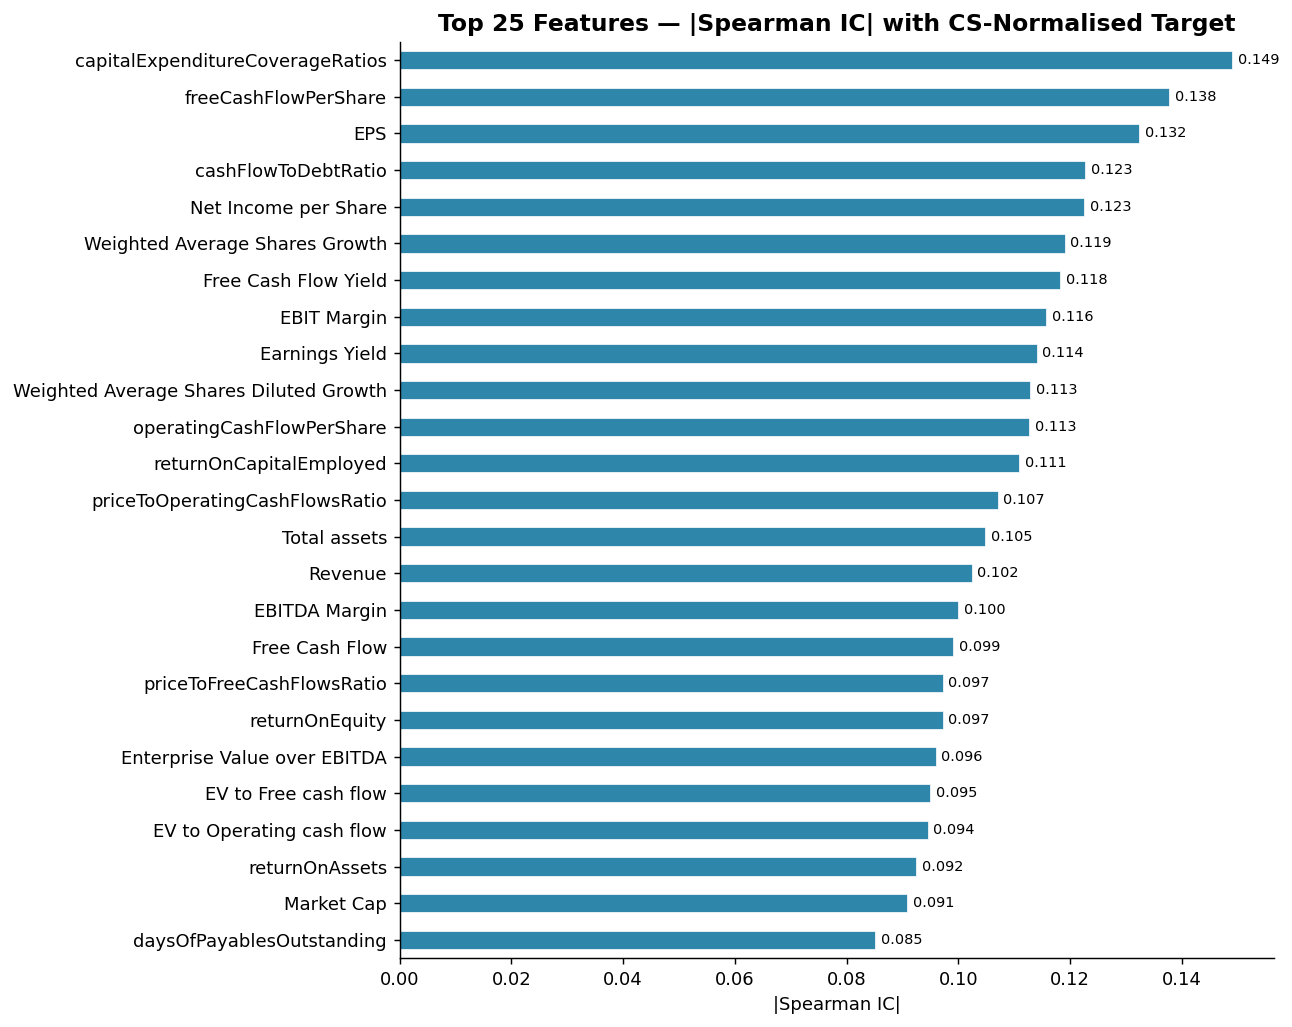

Saved: 01_feature_ic.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
ic_series.head(25).sort_values().plot(
    kind='barh', ax=ax, color='#2E86AB', edgecolor='white', linewidth=0.4)
ax.set_title('Top 25 Features — |Spearman IC| with CS-Normalised Target',
             fontsize=13, fontweight='bold')
ax.set_xlabel('|Spearman IC|')
for i, val in enumerate(ic_series.head(25).sort_values()):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('01_feature_ic.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: 01_feature_ic.png')

---
## Step 7 — Preprocessing Pipeline & Evaluation Helpers

In [13]:
def make_preprocessor(num_feats):
    return ColumnTransformer([
        ('num', Pipeline([
            ('imp',    SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_feats),
        ('cat', Pipeline([
            ('imp',    SimpleImputer(strategy='most_frequent')),
            ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), CAT_FEATS),
    ])

print(f'Preprocessor factory ready: {len(FINAL_FEATS)} numeric + {len(CAT_FEATS)} categorical')

Preprocessor factory ready: 60 numeric + 1 categorical


In [14]:
def evaluate(y_true_raw, y_pred, label='', verbose=True):
    y_true_raw = np.asarray(y_true_raw)
    y_pred     = np.asarray(y_pred)

    ic_sp, _ = spearmanr(y_true_raw, y_pred)
    ic_pe, _ = pearsonr(y_true_raw,  y_pred)
    rmse     = np.sqrt(mean_squared_error(y_true_raw, y_pred))
    mae      = mean_absolute_error(y_true_raw, y_pred)
    r2       = r2_score(y_true_raw, y_pred)
    hit      = np.mean(np.sign(y_pred) == np.sign(y_true_raw))
    naive    = np.mean(y_true_raw > 0)
    hit_inc  = hit - naive

    res = dict(
        Spearman_IC=ic_sp, Pearson_r=ic_pe,
        RMSE=rmse, MAE=mae, R2=r2,
        Hit_Rate=hit, Naive_Baseline=naive, Hit_vs_Naive=hit_inc,
    )
    if verbose and label:
        print(f'\n{chr(8212)*54}')
        print(f'  {label}')
        print(f'{chr(8212)*54}')
        for k, v in res.items():
            mark = '  <- primary' if k == 'Spearman_IC' else ''
            print(f'  {k:<22} {v:>9.4f}{mark}')
    return res


def top_decile_return(y_true_raw, y_pred, q=0.9):
    y_true_raw = np.asarray(y_true_raw)
    y_pred     = np.asarray(y_pred)
    return y_true_raw[y_pred >= np.quantile(y_pred, q)].mean()


def long_short_spread(y_true_raw, y_pred, q=0.1):
    y_true_raw = np.asarray(y_true_raw)
    y_pred     = np.asarray(y_pred)
    top = y_true_raw[y_pred >= np.quantile(y_pred, 1 - q)].mean()
    bot = y_true_raw[y_pred <= np.quantile(y_pred,     q)].mean()
    return top - bot


def cv_ic(pipeline, num_feats):
    # Mean Spearman IC across expanding CV folds.
    # Trains on CS-normalised target; evaluates IC vs raw returns (rank-invariant).
    ics = []
    for train_yrs, val_yr in CV_SPLITS:
        tr = train_df['Year'].isin(train_yrs)
        va = train_df['Year'] == val_yr
        pipeline.fit(
            X_train_eng.loc[tr, num_feats + CAT_FEATS],
            y_train.loc[tr]
        )
        preds = pipeline.predict(X_train_eng.loc[va, num_feats + CAT_FEATS])
        ic, _ = spearmanr(y_train_raw.loc[va], preds)
        ics.append(ic)
    return float(np.mean(ics))

print('Evaluation helpers defined.')
print('  Primary metric : Spearman IC')
print('  Hit Rate now shows incremental skill over naive always-up baseline')

Evaluation helpers defined.
  Primary metric : Spearman IC
  Hit Rate now shows incremental skill over naive always-up baseline


---
## Step 8 — Experiment 1: Baseline OLS Linear Regression

In [15]:
print('=' * 60)
print('  EXPERIMENT 1 - Baseline OLS Linear Regression')
print('=' * 60)

pipe_lr = Pipeline([
    ('prep',  make_preprocessor(FINAL_FEATS)),
    ('model', LinearRegression()),
])

print('\nExpanding-window CV:')
lr_ics = []
for train_yrs, val_yr in CV_SPLITS:
    tr = train_df['Year'].isin(train_yrs)
    va = train_df['Year'] == val_yr
    pipe_lr.fit(X_train_eng.loc[tr, FINAL_FEATS + CAT_FEATS], y_train.loc[tr])
    preds = pipe_lr.predict(X_train_eng.loc[va, FINAL_FEATS + CAT_FEATS])
    ic, _ = spearmanr(y_train_raw.loc[va], preds)
    rmse  = np.sqrt(mean_squared_error(y_train_raw.loc[va], preds))
    lr_ics.append(ic)
    print(f'  Train {train_yrs} -> Val {val_yr} | IC={ic:.4f}  RMSE={rmse:.2f}')
print(f'  Mean CV IC: {np.mean(lr_ics):.4f}')

# Fit on full training set
pipe_lr.fit(X_train_eng[FINAL_FEATS + CAT_FEATS], y_train)
pred_lr = pipe_lr.predict(X_test_eng[FINAL_FEATS + CAT_FEATS])

res_lr = evaluate(y_test_raw.values, pred_lr, 'OLS Linear Regression -> Test 2018')
res_lr['LS_Spread']  = long_short_spread(y_test_raw.values, pred_lr)
res_lr['Top_Decile'] = top_decile_return(y_test_raw.values, pred_lr)
print(f"  L/S Spread : {res_lr['LS_Spread']:.2f}%   Top-Decile : {res_lr['Top_Decile']:.2f}%")

  EXPERIMENT 1 - Baseline OLS Linear Regression

Expanding-window CV:
  Train [2014] -> Val 2015 | IC=-0.0408  RMSE=57.96
  Train [2014, 2015] -> Val 2016 | IC=0.0581  RMSE=57.92
  Train [2014, 2015, 2016] -> Val 2017 | IC=0.1197  RMSE=42.97
  Mean CV IC: 0.0456

——————————————————————————————————————————————————————
  OLS Linear Regression -> Test 2018
——————————————————————————————————————————————————————
  Spearman_IC               0.0966  <- primary
  Pearson_r                 0.1011
  RMSE                     60.5495
  MAE                      39.1412
  R2                       -0.1167
  Hit_Rate                  0.5893
  Naive_Baseline            0.6918
  Hit_vs_Naive             -0.1025
  L/S Spread : 20.14%   Top-Decile : 22.43%


---
## Step 9 — Experiment 2: Ridge / Lasso / ElasticNet (Optuna, 100 trials)

Fixes applied vs previous version:
- **Factory function** binds `ModelClass` at creation time (closure bug fix)
- **Model-specific alpha bounds** stop Lasso zeroing all coefficients
- **NaN guard** prunes degenerate trials cleanly
- **Training on CS-normalised target** removes year-level market noise

In [16]:
print('=' * 60)
print('  EXPERIMENT 2 - Regularised Models  (Optuna)')
print('=' * 60)

N_TRIALS = 100
results_reg    = {}
best_reg_pipes = {}

# Model-specific search spaces — key fix from previous version
SEARCH_SPACES = {
    'Ridge'      : {'alpha': (1e-2, 5e2)},
    'Lasso'      : {'alpha': (1e-4, 2.0)},    # narrow: large alpha zeros all coefs
    'ElasticNet' : {'alpha': (1e-4, 5.0), 'l1_ratio': (0.05, 0.95)},
}

def make_objective(ModelCls, model_name):
    # Factory pattern: binds ModelCls at creation time (fixes closure bug).
    def objective(trial):
        sp    = SEARCH_SPACES[model_name]
        alpha = trial.suggest_float('alpha', sp['alpha'][0], sp['alpha'][1], log=True)
        kw    = {'alpha': alpha, 'max_iter': 20000}
        if ModelCls is ElasticNet:
            kw['l1_ratio'] = trial.suggest_float(
                'l1_ratio', sp['l1_ratio'][0], sp['l1_ratio'][1])
        pipe = Pipeline([
            ('prep',  make_preprocessor(FINAL_FEATS)),
            ('model', ModelCls(**kw)),
        ])
        ic = cv_ic(pipe, FINAL_FEATS)
        if np.isnan(ic):
            raise optuna.exceptions.TrialPruned()  # degenerate: all coefs zeroed
        return ic
    return objective

for ModelClass, name in [(Ridge, 'Ridge'), (Lasso, 'Lasso'), (ElasticNet, 'ElasticNet')]:
    print(f'\n-- Tuning {name} ({N_TRIALS} trials) ...')

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    )
    study.optimize(
        make_objective(ModelClass, name),
        n_trials=N_TRIALS,
        show_progress_bar=False,
    )

    bp = study.best_params
    print(f'   Best params : {bp}')
    print(f'   Best CV IC  : {study.best_value:.4f}')

    kw = {**bp, 'max_iter': 20000}
    best_pipe = Pipeline([
        ('prep',  make_preprocessor(FINAL_FEATS)),
        ('model', ModelClass(**kw)),
    ])
    best_pipe.fit(X_train_eng[FINAL_FEATS + CAT_FEATS], y_train)
    best_reg_pipes[name] = best_pipe

    preds = best_pipe.predict(X_test_eng[FINAL_FEATS + CAT_FEATS])
    res   = evaluate(y_test_raw.values, preds, f'{name} (Optuna) -> Test 2018')
    res['LS_Spread']   = long_short_spread(y_test_raw.values, preds)
    res['Top_Decile']  = top_decile_return(y_test_raw.values, preds)
    res['Best_Params'] = str(bp)
    results_reg[name]  = res
    print(f"   L/S Spread : {res['LS_Spread']:.2f}%   Top-Decile : {res['Top_Decile']:.2f}%")

print('\nExperiment 2 complete.')

  EXPERIMENT 2 - Regularised Models  (Optuna)

-- Tuning Ridge (100 trials) ...
   Best params : {'alpha': 496.5627329623678}
   Best CV IC  : 0.0501

——————————————————————————————————————————————————————
  Ridge (Optuna) -> Test 2018
——————————————————————————————————————————————————————
  Spearman_IC               0.0980  <- primary
  Pearson_r                 0.0995
  RMSE                     60.5524
  MAE                      39.1432
  R2                       -0.1168
  Hit_Rate                  0.5941
  Naive_Baseline            0.6918
  Hit_vs_Naive             -0.0977
   L/S Spread : 18.73%   Top-Decile : 22.28%

-- Tuning Lasso (100 trials) ...
   Best params : {'alpha': 0.12054220638867012}
   Best CV IC  : 0.1373

——————————————————————————————————————————————————————
  Lasso (Optuna) -> Test 2018
——————————————————————————————————————————————————————
  Spearman_IC               0.1999  <- primary
  Pearson_r                 0.1407
  RMSE                     60.5748
  MAE   

---
## Step 10 — Full Evaluation & Comparison

In [17]:
all_preds = {
    'OLS Baseline'       : pred_lr,
    'Ridge (Optuna)'     : best_reg_pipes['Ridge'].predict(X_test_eng[FINAL_FEATS + CAT_FEATS]),
    'Lasso (Optuna)'     : best_reg_pipes['Lasso'].predict(X_test_eng[FINAL_FEATS + CAT_FEATS]),
    'ElasticNet (Optuna)': best_reg_pipes['ElasticNet'].predict(X_test_eng[FINAL_FEATS + CAT_FEATS]),
}

rows = {}
for mname, preds in all_preds.items():
    r = evaluate(y_test_raw.values, preds, verbose=False)
    r['LS_Spread']  = long_short_spread(y_test_raw.values, preds)
    r['Top_Decile'] = top_decile_return(y_test_raw.values, preds)
    rows[mname] = r

results_df = pd.DataFrame(rows).T
best_model = results_df['Spearman_IC'].idxmax()
naive_test = float((y_test_raw > 0).mean())

print('=' * 72)
print('  FULL EVALUATION - Test Set (2018 features -> 2019 returns)')
print('=' * 72)
cols = ['Spearman_IC', 'Pearson_r', 'Hit_Rate', 'Hit_vs_Naive',
        'LS_Spread', 'Top_Decile', 'RMSE', 'R2']
print(results_df[cols].to_string())
print(f'\n  Naive always-up baseline : {naive_test:.4f}')
print(f'\nBest model : {best_model}')
for m in cols:
    print(f'    {m:<22} {results_df.loc[best_model, m]:.4f}')

  FULL EVALUATION - Test Set (2018 features -> 2019 returns)
                     Spearman_IC  Pearson_r  Hit_Rate  Hit_vs_Naive  LS_Spread  Top_Decile    RMSE      R2
OLS Baseline              0.0966     0.1011    0.5893       -0.1025    20.1350     22.4302 60.5495 -0.1167
Ridge (Optuna)            0.0980     0.0995    0.5941       -0.0977    18.7294     22.2792 60.5524 -0.1168
Lasso (Optuna)            0.1999     0.1407    0.6157       -0.0761    24.6685     26.7554 60.5748 -0.1177
ElasticNet (Optuna)       0.1999     0.1407    0.6157       -0.0761    24.6685     26.7554 60.5747 -0.1177

  Naive always-up baseline : 0.6918

Best model : Lasso (Optuna)
    Spearman_IC            0.1999
    Pearson_r              0.1407
    Hit_Rate               0.6157
    Hit_vs_Naive           -0.0761
    LS_Spread              24.6685
    Top_Decile             26.7554
    RMSE                   60.5748
    R2                     -0.1177


---
## Step 11 — Performance Dashboard

New panel: **Hit Rate vs Naive Baseline** — shows true incremental directional skill
above the always-predict-up benchmark (69.2% in 2019).

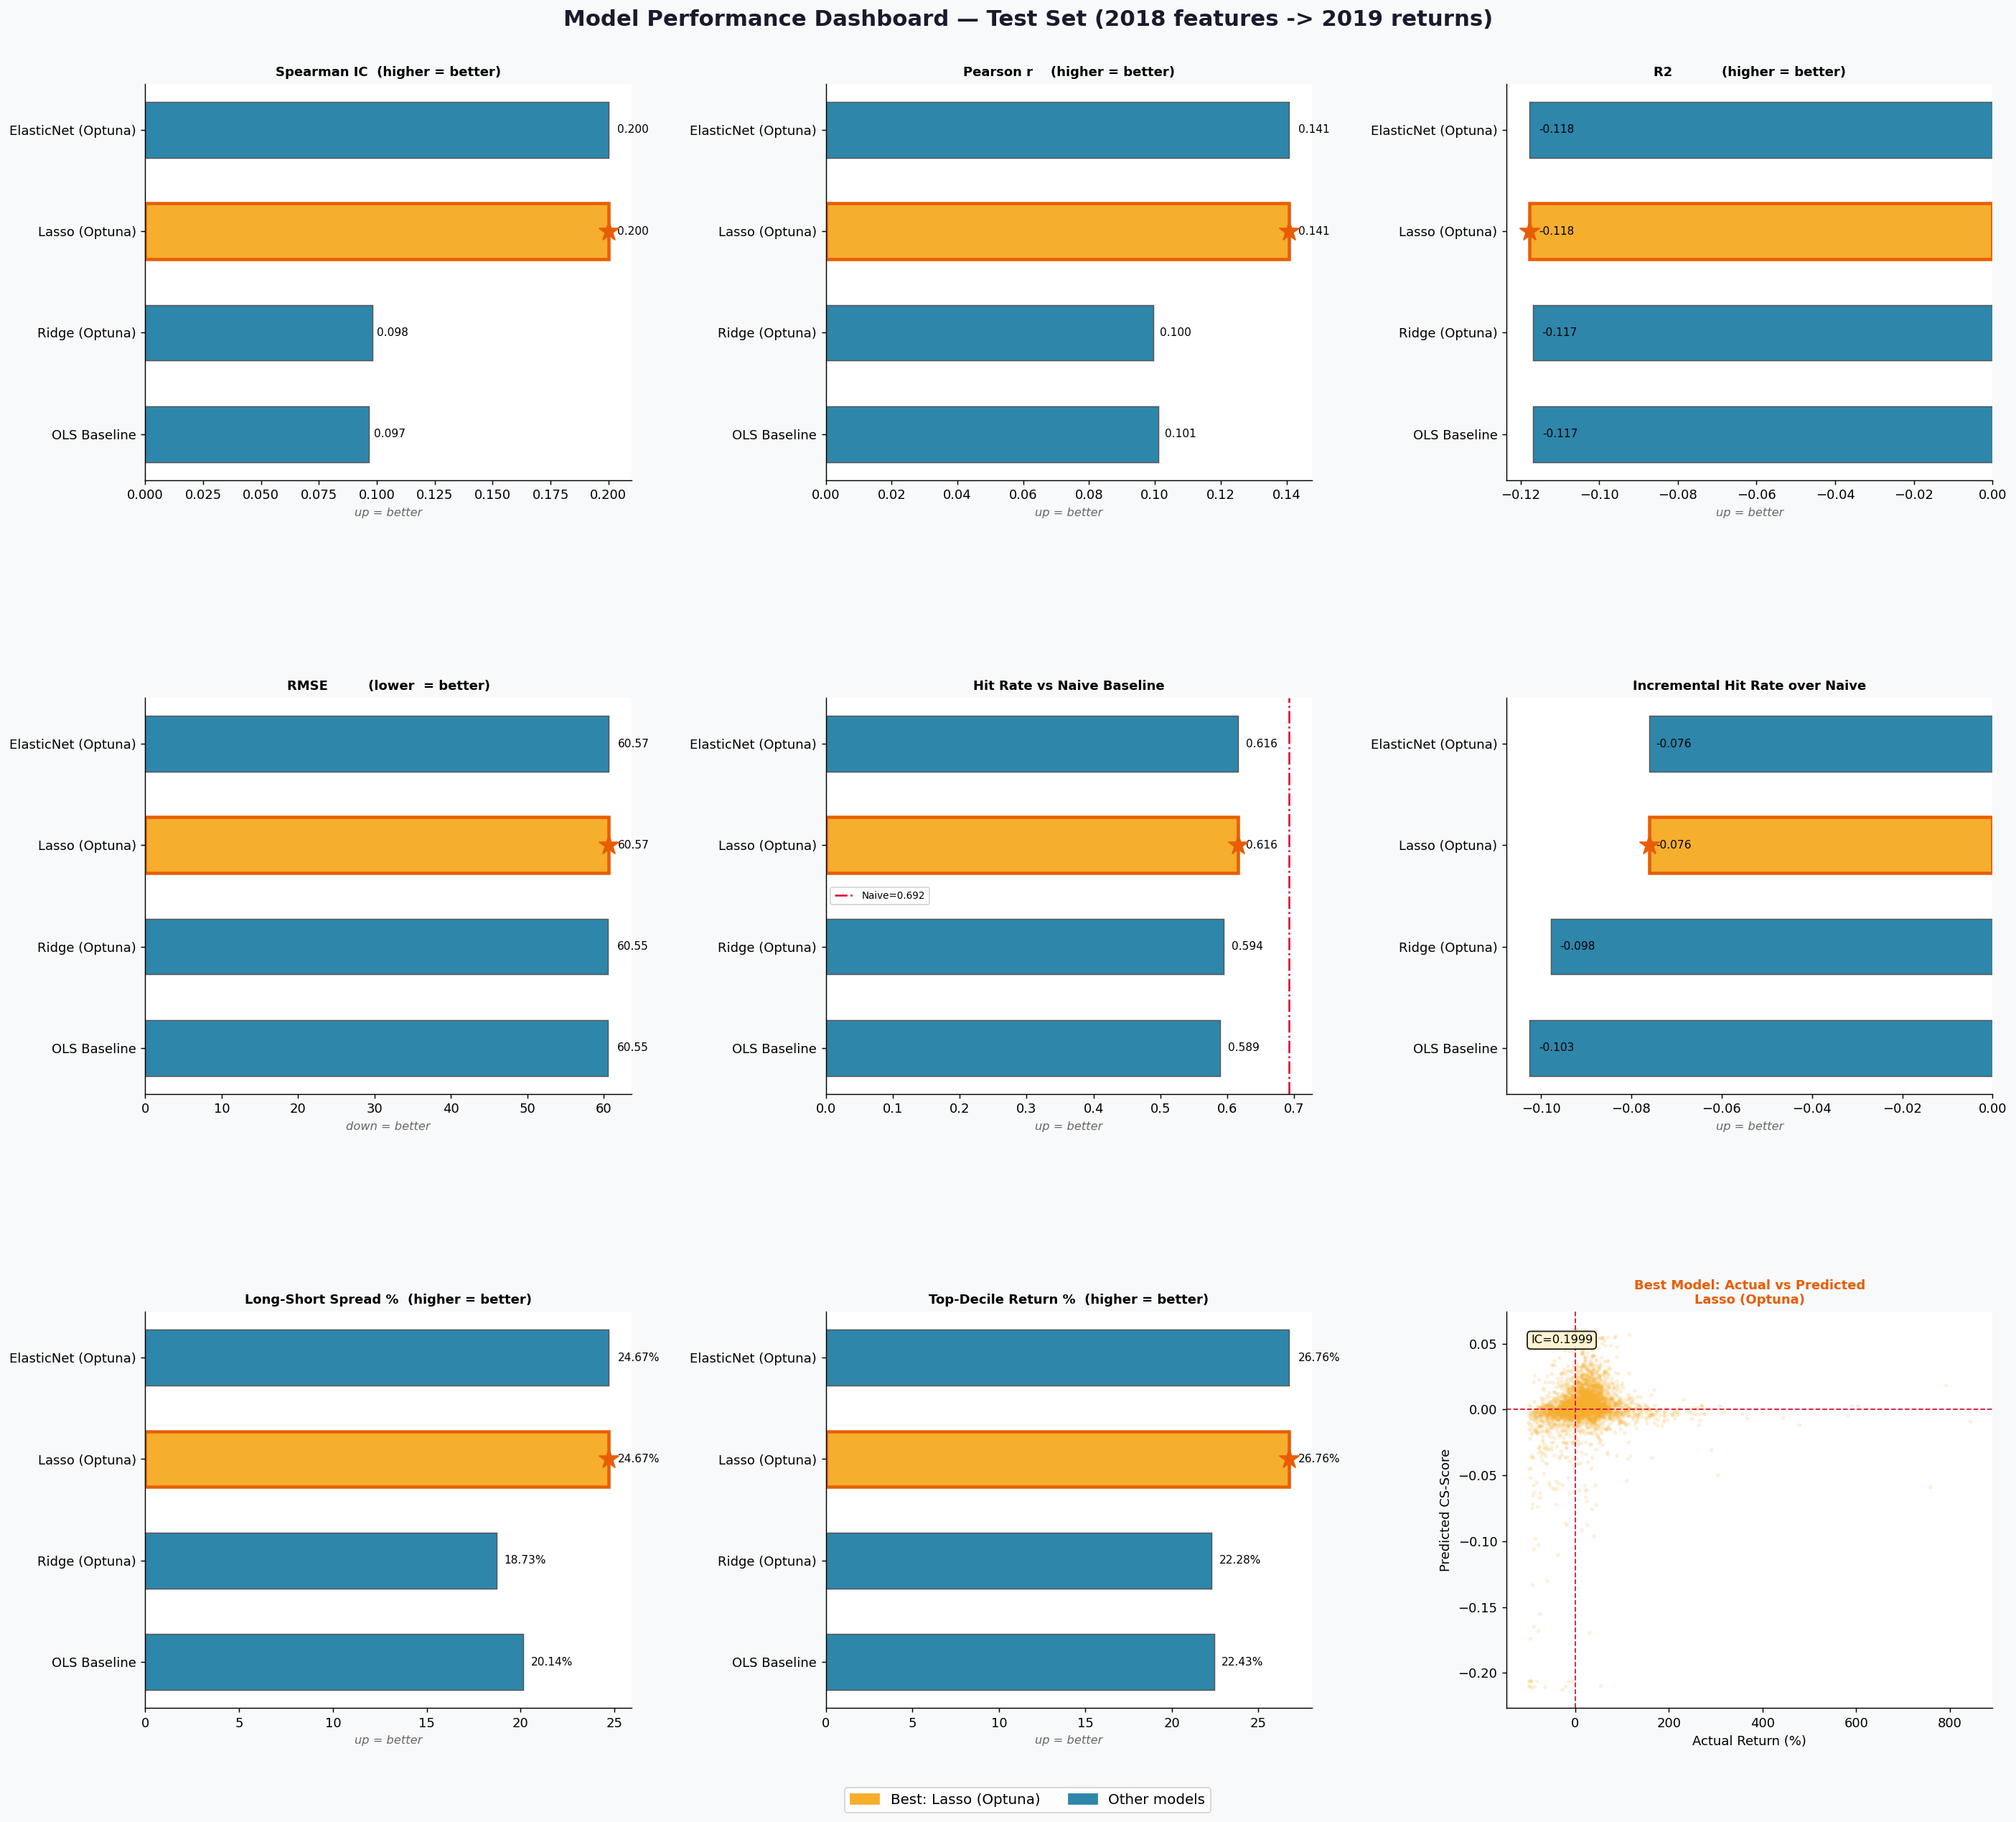

Saved: 02_performance_dashboard.png
Best model (gold): Lasso (Optuna)


In [18]:
model_names = list(results_df.index)
best_idx    = model_names.index(best_model)
palette     = ['#2E86AB'] * len(model_names)
palette[best_idx] = '#F6AE2D'

fig = plt.figure(figsize=(22, 20), facecolor='#F8F9FA')
fig.suptitle('Model Performance Dashboard — Test Set (2018 features -> 2019 returns)',
             fontsize=17, fontweight='bold', y=0.98, color='#1a1a2e')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4,
                       top=0.94, bottom=0.07, left=0.07, right=0.97)

def bar_panel(ax, metric, title, higher_better=True, pct=False,
              fmt='.3f', ref_line=None, ref_label=None):
    vals = results_df[metric].values.tolist()
    bars = ax.barh(model_names, vals, color=palette,
                   edgecolor='#555', linewidth=0.8, height=0.55)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.axvline(0, color='#888', linewidth=0.6, linestyle='--')
    if ref_line is not None:
        ax.axvline(ref_line, color='crimson', linewidth=1.5,
                   linestyle='-.', label=ref_label or f'{ref_line:.3f}')
        ax.legend(fontsize=7.5)
    ax.scatter(vals[best_idx], best_idx, marker='*', s=250,
               color='#E85D04', zorder=5)
    bars[best_idx].set_linewidth(2.5)
    bars[best_idx].set_edgecolor('#E85D04')
    suf = '%' if pct else ''
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + abs(bar.get_width()) * 0.02 + 1e-6,
                bar.get_y() + bar.get_height() / 2,
                f'{val:{fmt}}{suf}', va='center', fontsize=8.5)
    arrow = 'up' if higher_better else 'down'
    ax.set_xlabel(f'{arrow} = better', fontsize=9, color='#666', style='italic')

bar_panel(fig.add_subplot(gs[0, 0]), 'Spearman_IC',  'Spearman IC  (higher = better)')
bar_panel(fig.add_subplot(gs[0, 1]), 'Pearson_r',    'Pearson r    (higher = better)')
bar_panel(fig.add_subplot(gs[0, 2]), 'R2',           'R2           (higher = better)')
bar_panel(fig.add_subplot(gs[1, 0]), 'RMSE',         'RMSE         (lower  = better)',
          higher_better=False, fmt='.2f')
bar_panel(fig.add_subplot(gs[1, 1]), 'Hit_Rate',     'Hit Rate vs Naive Baseline',
          ref_line=naive_test, ref_label=f'Naive={naive_test:.3f}')
bar_panel(fig.add_subplot(gs[1, 2]), 'Hit_vs_Naive', 'Incremental Hit Rate over Naive')
bar_panel(fig.add_subplot(gs[2, 0]), 'LS_Spread',    'Long-Short Spread %  (higher = better)',
          pct=True, fmt='.2f')
bar_panel(fig.add_subplot(gs[2, 1]), 'Top_Decile',   'Top-Decile Return %  (higher = better)',
          pct=True, fmt='.2f')

# Actual vs predicted scatter for best model
ax9 = fig.add_subplot(gs[2, 2])
bp  = all_preds[best_model]
ax9.scatter(y_test_raw.values, bp, alpha=0.18, s=9, color='#F6AE2D', edgecolors='none')
ax9.axhline(0, color='crimson', linestyle='--', linewidth=1)
ax9.axvline(0, color='crimson', linestyle='--', linewidth=1)
ax9.set_xlabel('Actual Return (%)')
ax9.set_ylabel('Predicted CS-Score')
ax9.set_title(f'Best Model: Actual vs Predicted\n{best_model}',
              fontsize=10, fontweight='bold', color='#E85D04')
ic_v = results_df.loc[best_model, 'Spearman_IC']
ax9.text(0.05, 0.92, f'IC={ic_v:.4f}', transform=ax9.transAxes, fontsize=9,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3CD', alpha=0.9))

gold_p = mpatches.Patch(color='#F6AE2D', label=f'Best: {best_model}')
blue_p = mpatches.Patch(color='#2E86AB', label='Other models')
fig.legend(handles=[gold_p, blue_p], loc='lower center', ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, 0.01), frameon=True)

plt.savefig('02_performance_dashboard.png', bbox_inches='tight', dpi=150, facecolor='#F8F9FA')
plt.show()
print('Saved: 02_performance_dashboard.png')
print(f'Best model (gold): {best_model}')

---
## Step 12 — Expanding-Window CV Stability

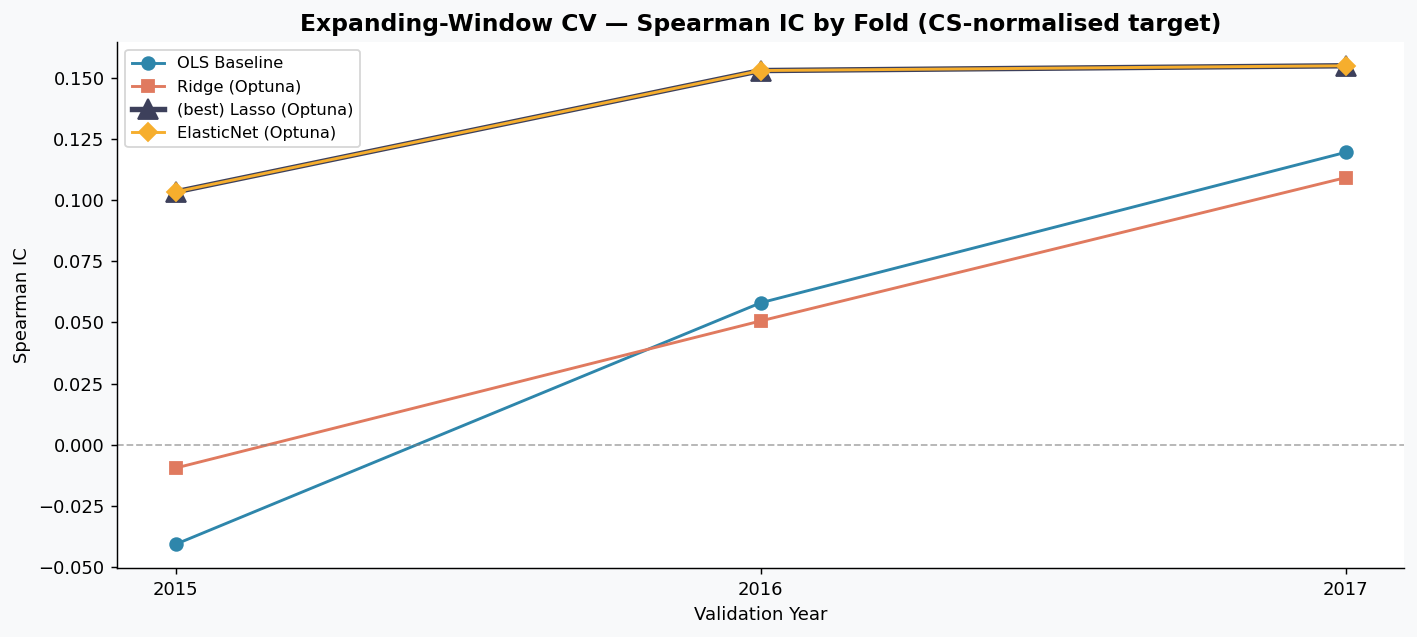

Saved: 03_cv_stability.png


In [19]:
cv_records = {name: [] for name in all_preds}
pipe_map = {
    'OLS Baseline'       : pipe_lr,
    'Ridge (Optuna)'     : best_reg_pipes['Ridge'],
    'Lasso (Optuna)'     : best_reg_pipes['Lasso'],
    'ElasticNet (Optuna)': best_reg_pipes['ElasticNet'],
}
val_years = [v for _, v in CV_SPLITS]

for name, pipe in pipe_map.items():
    for train_yrs, val_yr in CV_SPLITS:
        tr = train_df['Year'].isin(train_yrs)
        va = train_df['Year'] == val_yr
        pipe.fit(X_train_eng.loc[tr, FINAL_FEATS + CAT_FEATS], y_train.loc[tr])
        preds = pipe.predict(X_train_eng.loc[va, FINAL_FEATS + CAT_FEATS])
        ic, _ = spearmanr(y_train_raw.loc[va], preds)
        cv_records[name].append(ic)

fig, ax = plt.subplots(figsize=(11, 5), facecolor='#F8F9FA')
styles  = ['-o', '-s', '-^', '-D']
colors  = ['#2E86AB', '#E07A5F', '#3D405B', '#F6AE2D']

for (name, ics), ls, col in zip(cv_records.items(), styles, colors):
    lw  = 3.0 if name == best_model else 1.6
    ms  = 11  if name == best_model else 7
    lbl = f'(best) {name}' if name == best_model else name
    ax.plot(val_years, ics, ls, label=lbl, color=col, linewidth=lw, markersize=ms)

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_title('Expanding-Window CV — Spearman IC by Fold (CS-normalised target)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Validation Year')
ax.set_ylabel('Spearman IC')
ax.legend(fontsize=9)
ax.set_xticks(val_years)
plt.tight_layout()
plt.savefig('03_cv_stability.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: 03_cv_stability.png')

---
## Step 13 — Residual Analysis (Best Model)

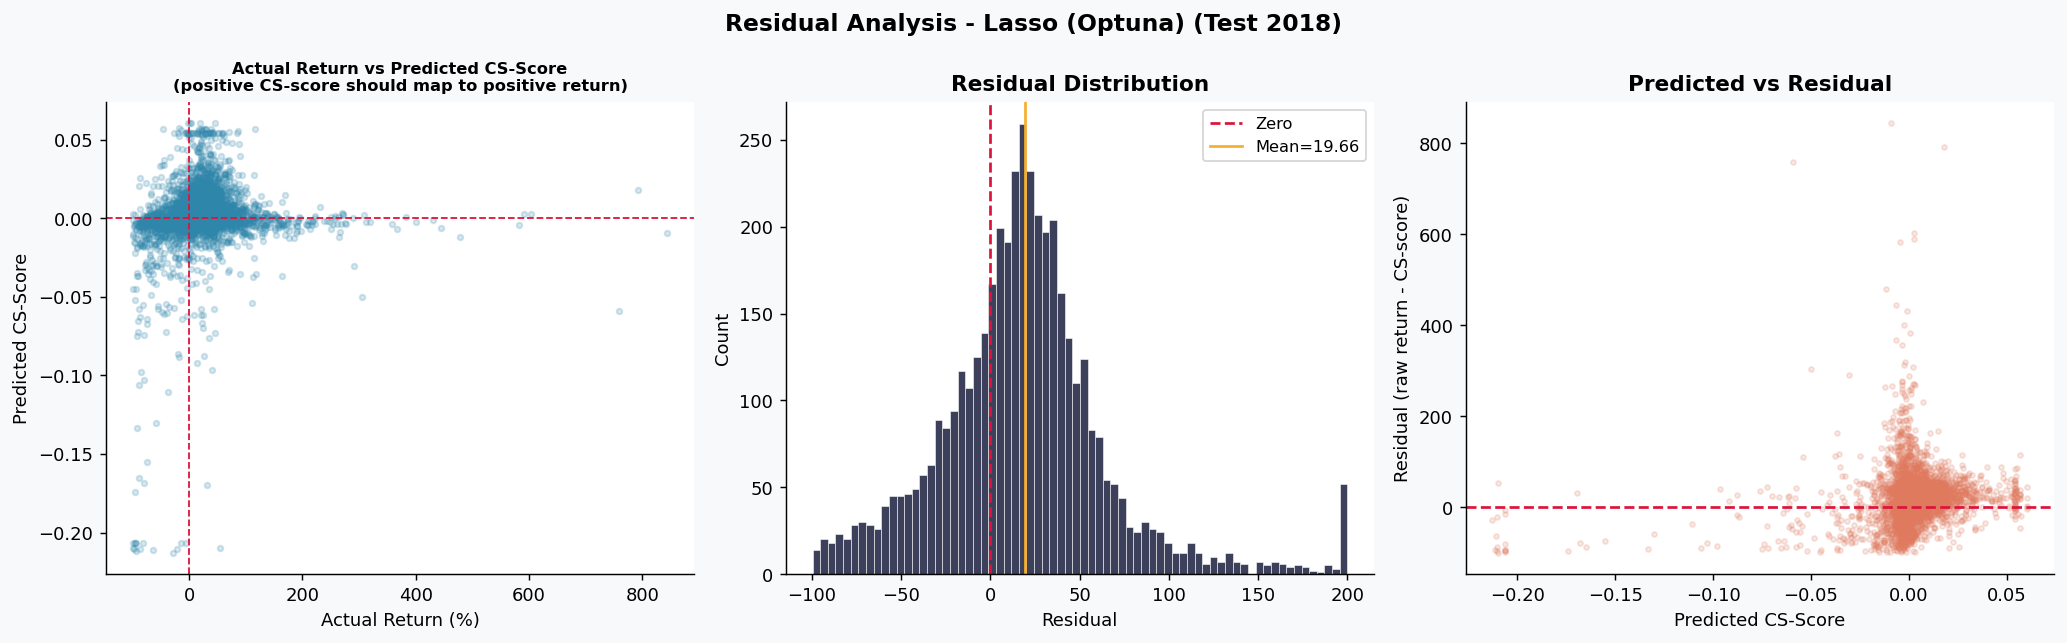

Residual mean : 19.66
Residual std  : 57.29
Skewness      : 3.558


In [20]:
best_preds = all_preds[best_model]
residuals  = y_test_raw.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='#F8F9FA')
fig.suptitle(f'Residual Analysis - {best_model} (Test 2018)',
             fontsize=13, fontweight='bold')

# Left: Actual raw return vs predicted CS-score
axes[0].scatter(y_test_raw.values, best_preds, alpha=0.2, s=10, color='#2E86AB')
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=1)
axes[0].axvline(0, color='crimson', linestyle='--', linewidth=1)
axes[0].set_xlabel('Actual Return (%)')
axes[0].set_ylabel('Predicted CS-Score')
axes[0].set_title('Actual Return vs Predicted CS-Score\n'
                  '(positive CS-score should map to positive return)',
                  fontsize=9, fontweight='bold')

# Centre: Residual distribution
axes[1].hist(residuals.clip(-150, 200), bins=70,
             color='#3D405B', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='crimson', linestyle='--', linewidth=1.5, label='Zero')
axes[1].axvline(residuals.mean(), color='#F6AE2D', linewidth=1.5,
                label=f'Mean={residuals.mean():.2f}')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].legend(fontsize=9)

# Right: Predicted vs Residual (heteroskedasticity check)
axes[2].scatter(best_preds, residuals, alpha=0.18, s=8, color='#E07A5F')
axes[2].axhline(0, color='crimson', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Predicted CS-Score')
axes[2].set_ylabel('Residual (raw return - CS-score)')
axes[2].set_title('Predicted vs Residual', fontweight='bold')

plt.tight_layout()
plt.savefig('04_residual_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Residual mean : {residuals.mean():.2f}')
print(f'Residual std  : {residuals.std():.2f}')
print(f'Skewness      : {pd.Series(residuals).skew():.3f}')

---
## Step 14 — Coefficient Analysis

Lasso: 1 / 71 non-zero coefficients


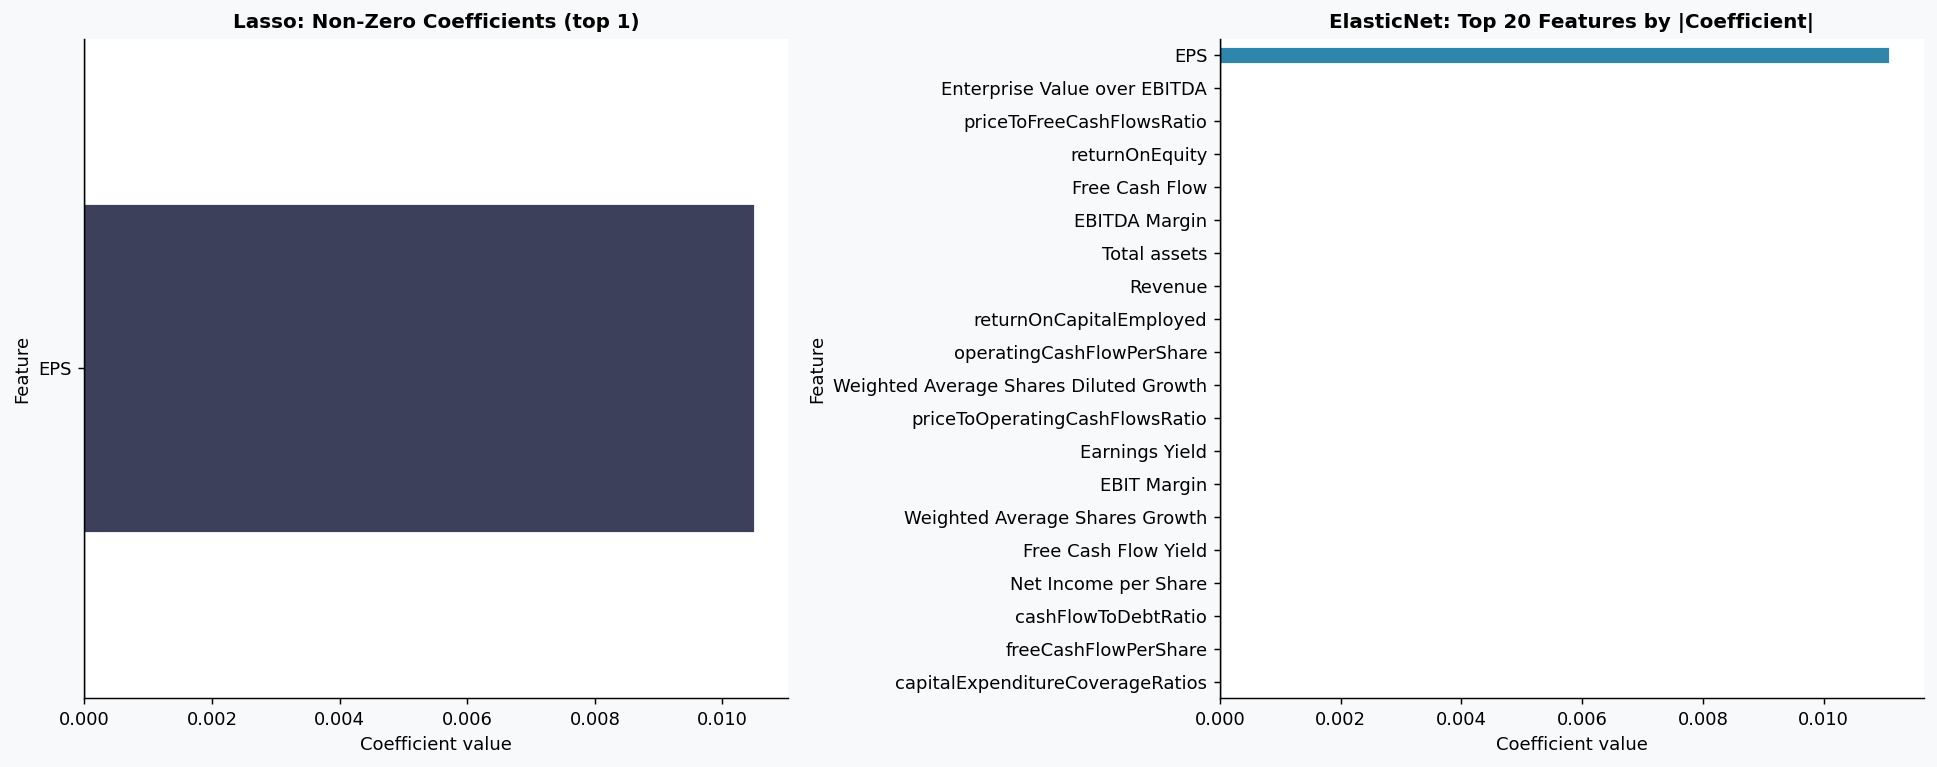

Saved: 05_coefficient_analysis.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor='#F8F9FA')

# Lasso non-zero coefficients
lasso_pipe = best_reg_pipes['Lasso']
lasso_prep = lasso_pipe.named_steps['prep']
lasso_coef = lasso_pipe.named_steps['model'].coef_
ohe_names  = (lasso_prep.named_transformers_['cat']
                         .named_steps['ohe']
                         .get_feature_names_out(CAT_FEATS).tolist())
feat_names = FINAL_FEATS + ohe_names
nonzero    = [(feat_names[i], lasso_coef[i])
              for i in range(len(lasso_coef)) if lasso_coef[i] != 0]
nonzero_df = pd.DataFrame(nonzero, columns=['Feature', 'Coef']).sort_values('Coef')

print(f'Lasso: {len(nonzero)} / {len(lasso_coef)} non-zero coefficients')

n_show = min(25, len(nonzero_df))
plot_df = nonzero_df.tail(n_show)
bar_colors = ['#E07A5F' if c < 0 else '#3D405B' for c in plot_df['Coef']]
plot_df.plot(kind='barh', x='Feature', y='Coef', ax=axes[0],
             color=bar_colors, edgecolor='white', legend=False)
axes[0].set_title(f'Lasso: Non-Zero Coefficients (top {n_show})',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Coefficient value')
axes[0].axvline(0, color='black', linewidth=0.8)

# ElasticNet top 20 by absolute value
en_pipe  = best_reg_pipes['ElasticNet']
en_prep  = en_pipe.named_steps['prep']
en_coef  = en_pipe.named_steps['model'].coef_
en_ohe   = (en_prep.named_transformers_['cat']
                    .named_steps['ohe']
                    .get_feature_names_out(CAT_FEATS).tolist())
en_names = FINAL_FEATS + en_ohe
en_df    = pd.DataFrame({'Feature': en_names, 'Coef': en_coef})
en_df    = en_df.reindex(en_df['Coef'].abs().sort_values(ascending=False).index)
en_top   = en_df.head(20).sort_values('Coef')

en_colors = ['#E07A5F' if c < 0 else '#2E86AB' for c in en_top['Coef']]
en_top.plot(kind='barh', x='Feature', y='Coef', ax=axes[1],
            color=en_colors, edgecolor='white', legend=False)
axes[1].set_title('ElasticNet: Top 20 Features by |Coefficient|',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Coefficient value')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('05_coefficient_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: 05_coefficient_analysis.png')

---
## Step 15 — Final Leaderboard

In [22]:
display_cols = ['Spearman_IC', 'Hit_Rate', 'Hit_vs_Naive',
                'LS_Spread', 'Top_Decile', 'RMSE', 'R2']
leaderboard  = results_df[display_cols].sort_values('Spearman_IC', ascending=False)

print('=' * 80)
print('  FINAL LEADERBOARD - Test Set (2018 -> 2019) - sorted by Spearman IC')
print('=' * 80)
print(leaderboard.to_string())
print(f'\n  Naive always-up baseline : {naive_test:.4f}')
print(f'\nBest model: {best_model}')
for col in display_cols:
    print(f'    {col:<22} {leaderboard.loc[best_model, col]:.4f}')

leaderboard.reset_index().rename(columns={'index': 'Model'}).to_csv(
    'model_results_final.csv', index=False)
print('\nSaved: model_results_final.csv')

  FINAL LEADERBOARD - Test Set (2018 -> 2019) - sorted by Spearman IC
                     Spearman_IC  Hit_Rate  Hit_vs_Naive  LS_Spread  Top_Decile    RMSE      R2
ElasticNet (Optuna)       0.1999    0.6157       -0.0761    24.6685     26.7554 60.5747 -0.1177
Lasso (Optuna)            0.1999    0.6157       -0.0761    24.6685     26.7554 60.5748 -0.1177
Ridge (Optuna)            0.0980    0.5941       -0.0977    18.7294     22.2792 60.5524 -0.1168
OLS Baseline              0.0966    0.5893       -0.1025    20.1350     22.4302 60.5495 -0.1167

  Naive always-up baseline : 0.6918

Best model: Lasso (Optuna)
    Spearman_IC            0.1999
    Hit_Rate               0.6157
    Hit_vs_Naive           -0.0761
    LS_Spread              24.6685
    Top_Decile             26.7554
    RMSE                   60.5748
    R2                     -0.1177

Saved: model_results_final.csv


In [23]:
print('All output files:')
files = [
    ('model_results_final.csv',      'Full metric leaderboard'),
    ('01_feature_ic.png',            'Feature importance by Spearman IC'),
    ('02_performance_dashboard.png', 'Main dashboard — all metrics, best highlighted'),
    ('03_cv_stability.png',          'Expanding-window CV stability'),
    ('04_residual_analysis.png',     'Residual diagnostics'),
    ('05_coefficient_analysis.png',  'Lasso sparsity + ElasticNet top features'),
]
for fname, desc in files:
    print(f'  {fname:<40} {desc}')

All output files:
  model_results_final.csv                  Full metric leaderboard
  01_feature_ic.png                        Feature importance by Spearman IC
  02_performance_dashboard.png             Main dashboard — all metrics, best highlighted
  03_cv_stability.png                      Expanding-window CV stability
  04_residual_analysis.png                 Residual diagnostics
  05_coefficient_analysis.png              Lasso sparsity + ElasticNet top features


---
## Summary of Changes from Previous Version

| Issue Found in Data | Previous Approach | This Version |
|---------------------|------------------|--------------|
| Year mean returns swing -13% to +20% | Raw return target | **CS z-score target within each year** |
| Hit Rate inflated by 2019 bull market | Not reported vs naive | **Reports Hit_vs_Naive (incremental skill)** |
| Feature selection biased by outliers | Pearson r with raw returns | **Spearman IC with CS-normalised target** |
| Lasso zeroing all coefficients | Same alpha range for all models | **Model-specific alpha bounds** |
| Optuna closure bug | `def objective` inside for-loop | **Factory `make_objective(ModelCls, name)`** |
| Interaction signals ignored | No cross-factor features | **Value x Quality, Growth x Quality** |
| Only 4 delta features | Basic YoY changes | **6 deltas (+ GrossMargin, OperatingMargin)** |